In [182]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io, plot
from cellpose.io import imread
from skimage.measure import label, regionprops
import pandas as pd


3919


Text(0.5, 1.0, '3919')

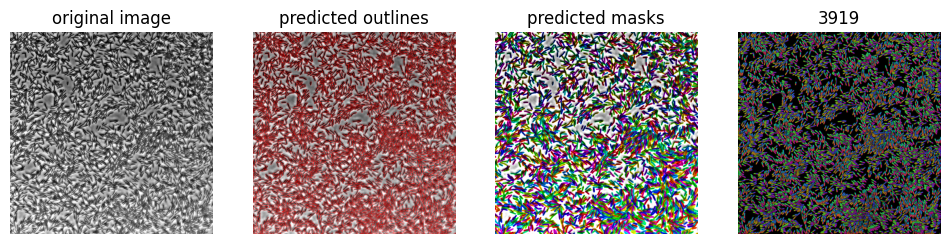

In [183]:
%matplotlib inline
model = models.CellposeModel(gpu=True)#, model_type = "cyto3")

# img = cv2.imread(r"C:\Users\victo\Downloads\HT1080\Odd_test\79_2\Raw\s79_20099.tif")[:1000,:,0]
img = imread(r"E:\BEER\star victor\cw\20x-0004.tif")#[:200,:200]

# cellpose 4.0
masks, flows, styles = model.eval(img, 
                                #  diameter=32., channels = [1,3],
                                    flow_threshold=.9,
                                    cellprob_threshold=-3,
                                #  min_size=20.,
                                #  niter=2000
                                    )# rescale= 27./280.)
print(len(np.unique(masks)))
# DISPLAY RESULTS

# overlay = plot.mask_overlay(img, masks)
# fig,axs = plt.subplots(1,2,figsize=(15,10))
# axs[0].imshow(overlay)
# axs[1].imshow(flows[0])

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img, masks, flows[0], channels=[0,0])
plt.title(len(np.unique(masks)))

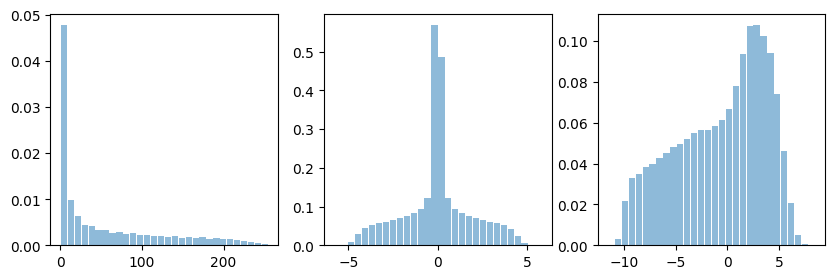

In [184]:
# cellpose 4.0
%matplotlib inline
fig, axs = plt.subplots(1, len(flows), figsize=(10,3))
for ax,flow in zip(axs,flows):
    ax.hist(flow.ravel(), bins=30, rwidth=.9, alpha=0.5, density=True)

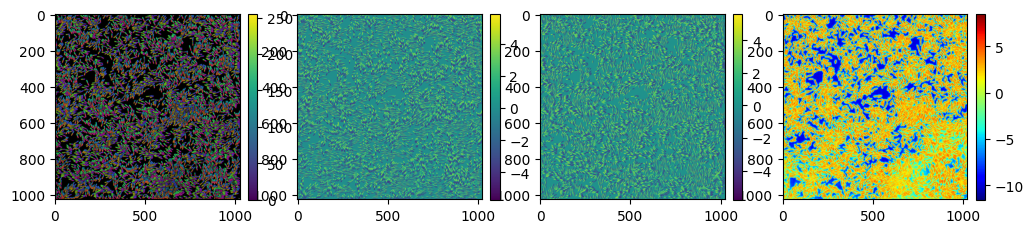

In [185]:
# cellpose 4.0
%matplotlib inline
fig, axs = plt.subplots(1, len(flows)+1, figsize=(12,5))
# for ax,flow in zip(axs,flows):
#     ax.imshow(flow)
c0 = axs[0].imshow(flows[0])
c1 = axs[1].imshow(flows[1][0])
c2 = axs[2].imshow(flows[1][1])
c3 = axs[3].imshow(flows[2], cmap='jet')
# Add colorbars to each subplot
fig.colorbar(c0, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(c1, ax=axs[1], fraction=0.046, pad=0.04)
fig.colorbar(c2, ax=axs[2], fraction=0.046, pad=0.04)
fig.colorbar(c3, ax=axs[3], fraction=0.046, pad=0.04)


In [186]:
%matplotlib qt
# plt.imshow(masks)
overlay = plot.mask_overlay(img, masks)
plt.imshow(overlay)
centers = np.array([region.centroid for region in regionprops(masks)])
# plt.imshow(img, cmap='gray')  # Display the original image
for center in centers:
    plt.plot(center[1], center[0], 'w.', alpha=.3)  # Plot centers in red

In [187]:
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img, masks, flows[0])

In [188]:
%matplotlib qt
# plt.imshow(plot.mask_overlay(img, masks))
plt.imshow(255-img, cmap='gray')
regions = regionprops(masks)
x_y_theta = pd.DataFrame([np.hstack([props.centroid, props.orientation]) for props in regions], columns=['y', 'x', 'theta'])

plt.quiver(
    x_y_theta['x'], x_y_theta['y'],
    -np.sin(x_y_theta['theta']), np.cos(x_y_theta['theta']), # <<< notice 
    headaxislength=0, headwidth=0, headlength=0, 
    color='r', pivot='mid', width=.02,
    scale=10, alpha=.3,
)
plt.plot(x_y_theta['x'], x_y_theta['y'], ".r", alpha=.6)  # Plot centers in white

In [193]:
# Create an empty image to store orientation values
orientation_img = np.zeros_like(masks, dtype=float)

[orientation_img.__setitem__((masks==region.label), region.orientation*180/np.pi) for region in regions]


plt.imshow(orientation_img, cmap='hsv', alpha=0.8)
plt.colorbar(label='Orientation (deg)')
plt.quiver(
    x_y_theta['x'], x_y_theta['y'],
    -np.sin(x_y_theta['theta']), np.cos(x_y_theta['theta']), # <<< notice 
    # headaxislength=0, headwidth=0, headlength=0, 
    color='k', pivot='mid', width=.01,
    scale=50, alpha=.3,
)


In [148]:
regions = regionprops(masks)
nn = [np.hstack([props.centroid, props.orientation]) for props in regions]

# for i,props in enumerate(regions):
#     print(
#         'label:', props.label, "\n",
#         'area:', props.area, "\n",
#         'centroid:',props.centroid, "\n",
#         'label:',props.eccentricity,"\n",
#         'perimeter:',props.perimeter, "\n",
#         'equivalent_diameter:',props.equivalent_diameter, "\n",
#         'orientation:',props.orientation,"\n",
#         'lamajor_axis_lengthbel:',props.major_axis_length, "\n",
#         'minor_axis_length:',props.minor_axis_length, "\n",
#         'solidity:',props.solidity,
#         )
#     break

In [149]:
nn[1]

array([ 5.60344828, 49.44252874,  1.17657237])

In [180]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage.draw import ellipse
from skimage.measure import label, regionprops, regionprops_table
from skimage.transform import rotate


image = np.zeros((600, 600))

rr, cc = ellipse(300, 350, 10, 100)
image[rr, cc] = 1
image = rotate(image, angle=50, order=0)

rr, cc = ellipse(100, 300, 20, 50)
image[rr, cc] = 1
image = rotate(image, angle=-30, order=0)

label_img = label(image)
regions = regionprops(label_img)

fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)

for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
    y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
    x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
    y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = props.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)
    print(orientation*180/np.pi)
    # break

ax.axis((0, 600, 600, 0))
plt.show()

60.000855549198924
-70.00185558336244
